## Training the Neural Additive Model (NAM) for correlated linear synthetic data


In [1]:
import json
import sys
from pathlib import Path

# Add src to path for imports
project_root = Path.cwd().parent.parent
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Get paths relative to project root
results_dir = project_root / 'results'
config_dir = project_root / 'config'

# Load best hyperparameters
best_hp_json = results_dir / 'hyperparameter_tuning' / 'nam' / 'hp_tuning_correlated_linear' / 'best_hp.json'
with open(best_hp_json, 'r') as f:
    best_hp = json.load(f)

# Load fixed training parameters from JSON
fixed_json = config_dir / 'training' / 'nam_training_parameters_correlated_linear.json'
with open(fixed_json, 'r') as f:
    fixed = json.load(f)

print(f"Loaded fixed training params from: {fixed_json}")


Loaded fixed training params from: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\config\training\nam_training_parameters_correlated_linear.json


In [2]:
rhos = [0, 0.3, 0.6, 0.8, 0.9, 0.95]
seeds = list(range(20))  # 20 dataset seeds per rho

# Set training output directory
project_root = Path.cwd().parent.parent
base_logdir = project_root / 'results' / 'training' / 'nam' / 'correlated_linear'
base_logdir.mkdir(parents=True, exist_ok=True)

skip_if_checkpoint_exists = True
per_run_timeout_s = 3600


In [3]:
from utils import run_nam_train_sweep

runs, summary_path = run_nam_train_sweep(
    rhos=rhos,
    seeds=seeds,
    fixed=fixed,
    best_hp=best_hp,
    base_logdir=base_logdir,
    skip_if_checkpoint_exists=skip_if_checkpoint_exists,
    per_run_timeout_s=per_run_timeout_s,
)


Instructions for updating:
non-resource variables are not supported in the long term

[rho=0, seed=0]
python -m neural_additive_models.nam_train --dataset_name=Correlated_linear --regression=true --activation=relu --shallow=true --num_basis_functions=128 --training_epochs=1000 --early_stopping_epochs=60 --batch_size=1024 --units_multiplier=2 --decay_rate=0.995 --tf_seed=1 --debug=true --use_dnn=false --n_models=1 --max_checkpoints_to_keep=1 --save_checkpoint_every_n_epochs=10 --hyperparameter_tuning=true --combine_train_val_for_final_training=true --num_splits=1 --data_split=1 --fold_num=1 --correlated_n=20000 --correlated_rho=0 --correlated_seed=0 --test_size=0.2 --val_size=0.2 --hp_random_state=42 --logdir=correlated_linear\rho_0\seed_0 --dropout=0.3 --l2_regularization=3.32647082621911e-05 --learning_rate=0.024808857993184677 --feature_dropout=0 --output_regularization=0.029940175102259513
  OK in 128.9s

[rho=0, seed=1]
python -m neural_additive_models.nam_train --dataset_name=Corr

In [3]:
import neural_additive_models.data_utils as data_utils
from utils import load_col_min_max, inverse_min_max_scaler

dataset_name = 'Correlated_linear'
correlated_n = 20000
rho = 0.95
seed = 0
is_regression = True
data =  data_utils.load_dataset(dataset_name, correlated_n, rho, seed)
data_x, data_y, column_names = data
col_min_max = load_col_min_max(dataset_name, correlated_n, rho, seed)


Instructions for updating:
non-resource variables are not supported in the long term


In [4]:
from utils import get_hyperparameter_tuning_indices

fold_train_indices, fold_test_indices = get_hyperparameter_tuning_indices(
    data_x,
    data_y,
    test_size=0.2,
    val_size=0.2,
    is_regression=True,
    random_state=42,  # Must match hp_random_state from training
    combine_train_val=True,  # ← Set to True if combine_train_val_for_final_training=true
)


In [5]:
from utils import prepare_feature_arrays, get_dataset_config

# Step 1: Prepare data
SINGLE_FEATURES_ORIGINAL, UNIQUE_FEATURES_ORIGINAL, UNIQUE_FEATURES = prepare_feature_arrays(
    data_x, column_names, col_min_max, inverse_min_max_scaler
)

# Step 2: Load dataset-specific config
COL_NAMES, FEATURE_LABEL_MAPPING, CATEGORICAL_NAMES = get_dataset_config(dataset_name, column_names)


Processing seed 0...
Using checkpoint: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training\nam\correlated_linear/rho_095/seed_0/fold_1/split_1/model_0/best_checkpoint\model.ckpt-3900
Feature widths: [128, 128, 128, 128, 128, 128, 128, 128, 128, 128]
Num input features: 10
INFO:tensorflow:Restoring parameters from c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training\nam\correlated_linear/rho_095/seed_0/fold_1/split_1/model_0/best_checkpoint\model.ckpt-3900
✅ Restored NAM from checkpoint.
Using checkpoint: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training\nam\correlated_linear/rho_095/seed_1/fold_1/split_1/model_0/best_checkpoint\model.ckpt-1170
Feature widths: [128, 128, 128, 128, 128, 128, 128, 128, 128, 128]
Num input features: 10
INFO:tensorflow:Restoring parameters from c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training

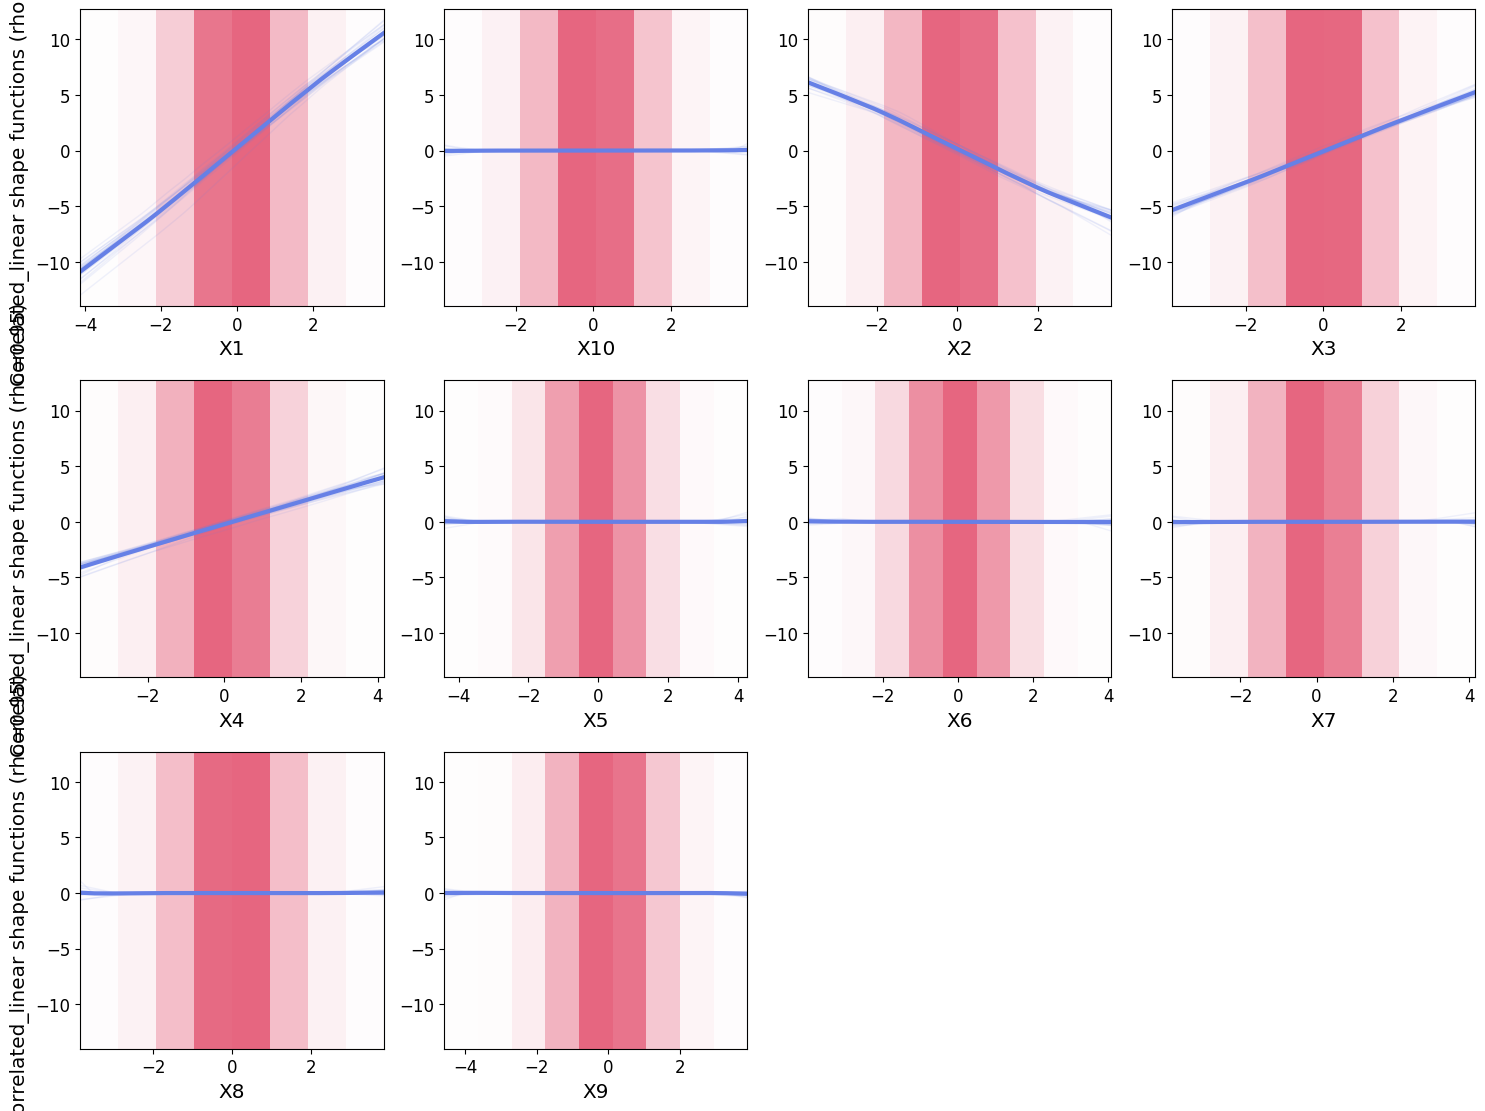

In [7]:
from utils import analyze_correlated_shape_functions, plot_nam_contributions_with_density

dataset_name = "Correlated_linear"
rho = 0.95
seeds = list(range(20))

TRUE_COEFS = {
    "X1": 3.0,
    "X2": -2.0,
    "X3": 1.5,
    "X4": 1.0,
}

(
    seed_rmses,
    all_hist_data,
    all_mean_pred,
    UNIQUE_FEATURES_ORIGINAL,
    SINGLE_FEATURES_ORIGINAL,
    column_names,
) = analyze_correlated_shape_functions(
    dataset_name=dataset_name,
    rho=rho,
    seeds=seeds,
    fixed=fixed,
    best_hp=best_hp,
    fold_num_trained=1,
    n_folds=2,
    split_num_trained=1,
    random_state=42,
    n_grid=400,
    ckpt_base_dir=str(base_logdir),
    print_every=5,
)

col_mapping = {c: c for c in column_names}
feature_mapping = {}
categorical_names = []

fig = plot_nam_contributions_with_density(
    hist_data=all_hist_data,
    unique_features=UNIQUE_FEATURES_ORIGINAL,
    single_features=SINGLE_FEATURES_ORIGINAL,
    categorical_names=categorical_names,
    col_mapping=col_mapping,
    feature_mapping=feature_mapping,
    mean_pred=all_mean_pred,
    feature_to_use=column_names,
    dataset_label=f"{dataset_name} shape functions (rho={rho})",
)


In [8]:
from utils import evaluate_correlated_models

# Define true coefficients for linear dataset
TRUE_COEFS = {
    "X1": 3.0,
    "X2": -2.0,
    "X3": 1.5,
    "X4": 1.0,
}

# Both metrics (true_coefs required for Correlated_linear)
(rmse_by_rho_seed, rmse_df, summary, rho_rmses), (shape_df, shape_by_rho_seed_feature) = evaluate_correlated_models(
    dataset_name="Correlated_linear",
    rhos=rhos,
    seeds=seeds,
    fixed=fixed,
    best_hp=best_hp,
    compute_shape_rmse=True,
    true_coefs=TRUE_COEFS,
    ckpt_base_dir=str(base_logdir)
)


Using checkpoint: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training\nam\correlated_linear/rho_0/seed_0/fold_1/split_1/model_0/best_checkpoint\model.ckpt-1040
Feature widths: [128, 128, 128, 128, 128, 128, 128, 128, 128, 128]
Num input features: 10
INFO:tensorflow:Restoring parameters from c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training\nam\correlated_linear/rho_0/seed_0/fold_1/split_1/model_0/best_checkpoint\model.ckpt-1040
✅ Restored NAM from checkpoint.
Using checkpoint: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training\nam\correlated_linear/rho_0/seed_1/fold_1/split_1/model_0/best_checkpoint\model.ckpt-1430
Feature widths: [128, 128, 128, 128, 128, 128, 128, 128, 128, 128]
Num input features: 10
INFO:tensorflow:Restoring parameters from c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training\nam\correlated_linear/rho_

In [9]:
# Display and save test RMSE summary (mean and std per rho)
import json

print("="*70)
print("TEST RMSE SUMMARY BY RHO (Correlated Linear)")
print("="*70)
print(summary.to_string(index=False))
print("="*70)

# Save to JSON
results_dir = project_root / 'results' / 'evaluation'
results_dir.mkdir(parents=True, exist_ok=True)

summary_json = results_dir / 'correlated_linear_rmse_summary.json'
with open(summary_json, 'w') as f:
    json.dump({
        'dataset': 'Correlated_linear',
        'summary': summary.to_dict('records')
    }, f, indent=2)

rmse_df_json = results_dir / 'correlated_linear_rmse_full.json'
with open(rmse_df_json, 'w') as f:
    json.dump({
        'dataset': 'Correlated_linear',
        'rmse_by_rho_seed': rmse_df.to_dict('records')
    }, f, indent=2)

print(f"\nSaved summary to: {summary_json}")
print(f"Saved full RMSE data to: {rmse_df_json}")


TEST RMSE SUMMARY BY RHO (Correlated Linear)
 rho     mean      std  count
0.00 0.505189 0.006160     20
0.30 0.504721 0.006077     20
0.60 0.505361 0.006272     20
0.80 0.505748 0.005864     20
0.90 0.506488 0.005672     20
0.95 0.507996 0.005604     20

Saved summary to: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\evaluation\correlated_linear_rmse_summary.json
Saved full RMSE data to: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\evaluation\correlated_linear_rmse_full.json


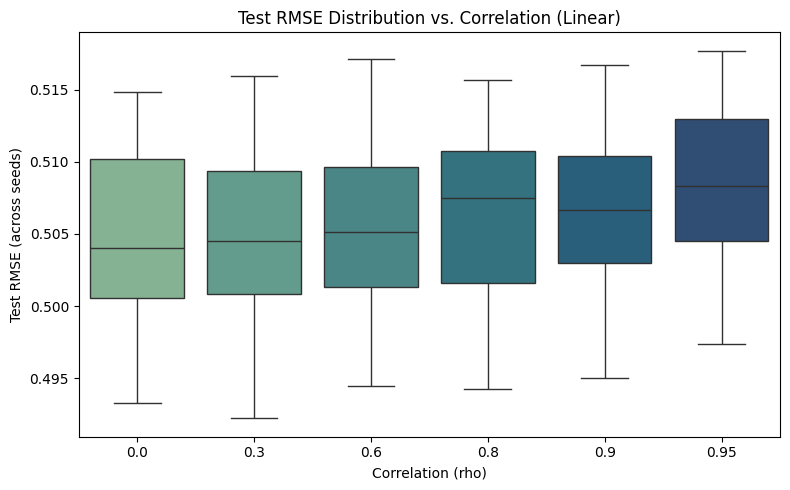

In [ ]:
from utils import plot_rmse_boxplot_vs_rho

plot_rmse_boxplot_vs_rho(rmse_df, dataset_label="Linear")


Shape RMSE Statistics:
   Overall mean: 1.2588
   Overall std: 1.6543
   Min: 0.0051
   Max: 6.0101

Per-feature average shape RMSE (mean ± std):
   X9: 0.0488 ± 0.0270
   X10: 0.0555 ± 0.0302
   X7: 0.0594 ± 0.0464
   X5: 0.0638 ± 0.0451
   X8: 0.0667 ± 0.0491
   X6: 0.0686 ± 0.0387
   X4: 1.7635 ± 0.1512
   X3: 2.4555 ± 0.2016
   X2: 3.0964 ± 0.3830
   X1: 4.9100 ± 0.3400


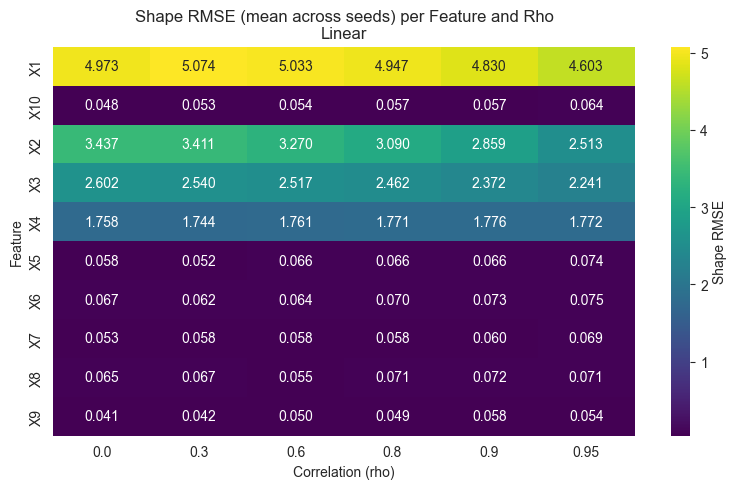

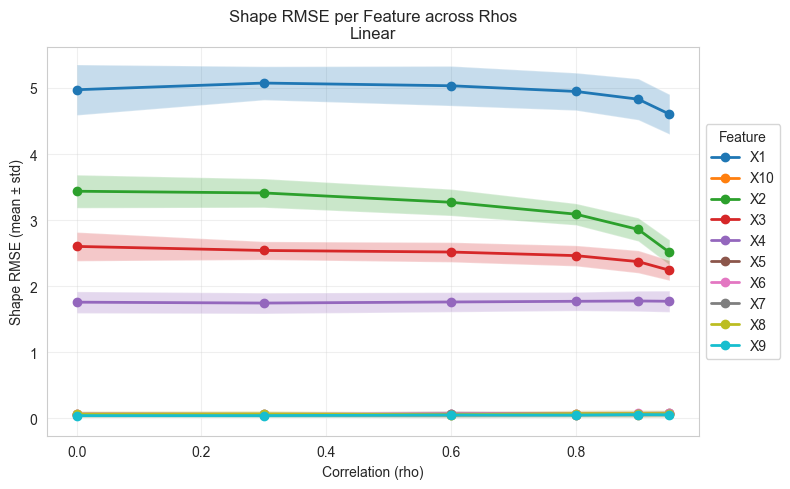

In [ ]:
from utils import analyze_shape_rmse

analyze_shape_rmse(shape_df, dataset_label="Linear")
